# This is Alzheimer disease prediction in age 60 - 90 years

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# --- 1. Load Data and Preprocessing ---

# Load the data
df = pd.read_csv("oasis_longitudinal.csv")

# Filter for the baseline visit (Visit 1)
df_baseline = df[df['Visit'] == 1].copy()

# Drop columns not needed for this baseline model
cols_to_drop = ['Subject ID', 'MRI ID', 'Visit', 'MR Delay', 'Hand', 'ASF']
df_baseline.drop(columns=cols_to_drop, inplace=True)

# Drop the 'Converted' group to focus on a binary Nondemented vs Demented classification
df_baseline = df_baseline[df_baseline['Group'] != 'Converted']

# Convert 'Group' to binary: Demented=1, Nondemented=0 (Target variable)
le = LabelEncoder()
df_baseline['Group_Encoded'] = le.fit_transform(df_baseline['Group'])
y = df_baseline['Group_Encoded']
X = df_baseline.drop(columns=['Group', 'Group_Encoded'])

# Handle Missing Values (SES, MMSE) by imputing with the median
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
X[['SES', 'MMSE']] = imputer.fit_transform(X[['SES', 'MMSE']])

# Handle Categorical Features (M/F) using One-Hot Encoding
X = pd.get_dummies(X, columns=['M/F'], drop_first=True)

In [4]:
# --- 2. Data Split ---

# Split into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [5]:
# --- 3. Model Training (Random Forest) ---

# Initialize the Random Forest Classifier
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

# Train the model
rf_clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [6]:
# --- 4. Evaluation and Prediction ---

y_pred = rf_clf.predict(X_test)
y_proba = rf_clf.predict_proba(X_test)[:, 1]

In [7]:
# Print Metrics
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Nondemented', 'Demented'])
print("--- Model Evaluation Metrics ---")
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)

--- Model Evaluation Metrics ---
Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

 Nondemented       1.00      1.00      1.00        19
    Demented       1.00      1.00      1.00        22

    accuracy                           1.00        41
   macro avg       1.00      1.00      1.00        41
weighted avg       1.00      1.00      1.00        41



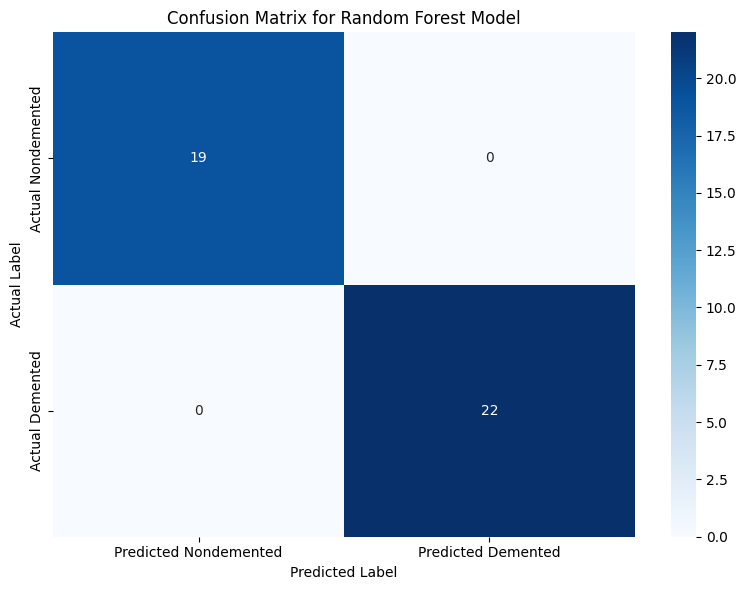

In [9]:
# Save Confusion Matrix Plot
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Nondemented', 'Predicted Demented'],
            yticklabels=['Actual Nondemented', 'Actual Demented'])
plt.title('Confusion Matrix for Random Forest Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

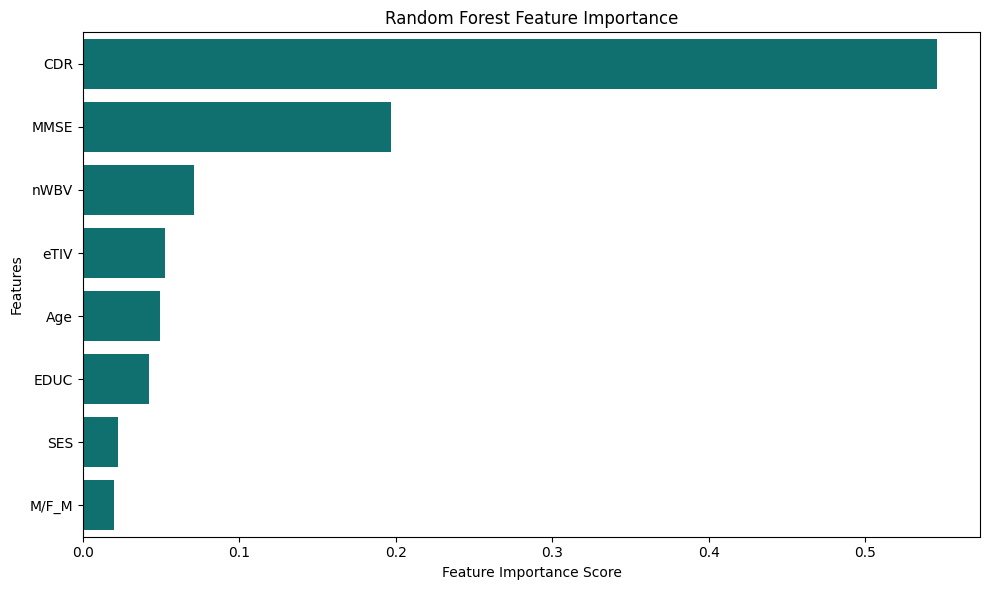

In [10]:
# Save Feature Importance Plot
importance = pd.Series(rf_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values, y=importance.index, color='teal')
plt.title('Random Forest Feature Importance')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [11]:
# Display sample predictions
results_df = X_test.head().copy()
results_df['Actual_Group'] = y_test.head().map({0: 'Nondemented', 1: 'Demented'})
results_df['Predicted_Group'] = y_pred[:5]
results_df['Predicted_Group'] = results_df['Predicted_Group'].map({0: 'Nondemented', 1: 'Demented'})
results_df['Demented_Probability'] = y_proba[:5].round(4)
print("\nPrediction results on the first 5 test samples:\n", results_df.to_markdown(numalign="left", stralign="left"))


Prediction results on the first 5 test samples:
 |     | Age   | EDUC   | SES   | MMSE   | CDR   | eTIV   | nWBV   | M/F_M   | Actual_Group   | Predicted_Group   | Demented_Probability   |
|:----|:------|:-------|:------|:-------|:------|:-------|:-------|:--------|:---------------|:------------------|:-----------------------|
| 43  | 86    | 12     | 4     | 21     | 0.5   | 1247   | 0.662  | False   | Nondemented    | Nondemented       | 0.11                   |
| 5   | 88    | 18     | 3     | 28     | 0     | 1215   | 0.71   | False   | Demented       | Demented          | 0.895                  |
| 233 | 76    | 12     | 3     | 27     | 0.5   | 1315   | 0.698  | False   | Nondemented    | Nondemented       | 0.03                   |
| 177 | 82    | 12     | 4     | 26     | 0.5   | 1271   | 0.695  | False   | Nondemented    | Nondemented       | 0.07                   |
| 22  | 81    | 12     | 4     | 30     | 0     | 1230   | 0.715  | False   | Demented       | Demented       

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# --- 1. Model Training Setup (Required to initialize the model and preprocessors) ---
# This section re-trains the model every time to ensure the prediction function works consistently.

# Load the data
df = pd.read_csv("oasis_longitudinal.csv")

# Filter for the baseline visit (Visit 1) and drop 'Converted' group
df_baseline = df[df['Visit'] == 1].copy()
cols_to_drop = ['Subject ID', 'MRI ID', 'Visit', 'MR Delay', 'Hand', 'ASF']
df_baseline.drop(columns=cols_to_drop, inplace=True)
df_baseline = df_baseline[df_baseline['Group'] != 'Converted']

# Prepare target and features
le = LabelEncoder()
df_baseline['Group_Encoded'] = le.fit_transform(df_baseline['Group'])
y = df_baseline['Group_Encoded']
X = df_baseline.drop(columns=['Group', 'Group_Encoded'])

# Impute missing values and store median for later use
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
X[['SES', 'MMSE']] = imputer.fit_transform(X[['SES', 'MMSE']])
median_ses = imputer.statistics_[0]
median_mmse = imputer.statistics_[1]

# Handle Categorical Features (M/F)
X = pd.get_dummies(X, columns=['M/F'], drop_first=True)

# Split and Train the Random Forest Classifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced')
rf_clf.fit(X_train, y_train)

# --- 2. Single Data Prediction Function ---

def predict_single_data(age, educ, ses, mmse, cdr, etiv, nwbv, gender):
    """
    Predicts the Alzheimer's group (Nondemented or Demented) for a single data point
    using the trained Random Forest model.

    Returns: (Predicted Class: str, Demented Probability: float)
    """
    # 1. Create a DataFrame from the input data
    new_data = pd.DataFrame([{
        'Age': age, 'EDUC': educ, 'SES': ses, 'MMSE': mmse, 'CDR': cdr,
        'eTIV': etiv, 'nWBV': nwbv, 'M/F': gender
    }])

    # 2. Imputation: Replace NaN in SES/MMSE with the stored median from training
    if new_data['SES'].isnull().any():
        new_data.loc[:, 'SES'] = new_data['SES'].fillna(median_ses)
    if new_data['MMSE'].isnull().any():
        new_data.loc[:, 'MMSE'] = new_data['MMSE'].fillna(median_mmse)

    # 3. One-Hot Encoding for 'M/F'
    new_data = pd.get_dummies(new_data, columns=['M/F'], drop_first=True)

    # 4. Align features with training data
    required_cols = list(X.columns)

    if 'M/F_M' not in new_data.columns:
        new_data['M/F_M'] = 0

    X_new = new_data[required_cols]

    # 5. Prediction
    prediction_proba = rf_clf.predict_proba(X_new)[0]

    # Identify the index corresponding to 'Demented' class
    # np.where ensures we get the correct index regardless of the LabelEncoder's order (0 or 1)
    demented_index = np.where(le.classes_ == 'Demented')[0][0]

    demented_proba = prediction_proba[demented_index]

    # Final classification based on 50% threshold
    if demented_proba >= 0.5:
        class_name = "Demented"
    else:
        class_name = "Nondemented"

    return class_name, demented_proba

# -------------------------------------------------------------
# --- 3. USER INPUT AREA: EDIT THESE VALUES FOR YOUR SUBJECT ---
# -------------------------------------------------------------

# Example: An 85-year-old male with low cognition and mild dementia symptoms.
# ---
# NOTE: If SES or MMSE is unknown, use 'None' (e.g., ses=None).
print("\nEnter Age:")
age = int(input()) # Age in years "10"
print("\nEnter year of Education:")
educ = int(input())     # Years of education "10"
print("\nEnter Socioeconomic Status (1 to 4):")
ses = int(input())     # Socioeconomic Status (1 to 4) "3.0"
print("\nEnter Mini-Mental State Exam (0 to 30):")
mmse = int(input())   # Mini-Mental State Exam (0 to 30)   "20.0"
print("\nEnter Clinical Dementia Rating (0.0, 0.5, 1.0, 2.0):")
cdr = float(input())     # Clinical Dementia Rating (0.0, 0.5, 1.0, 2.0) "1.0"
print("\nEnter Estimated Total Intracranial Volume (int):")
etiv = int(input())   # Estimated Total Intracranial Volume (int) "1400"
print("\nEnter Normalized Whole Brain Volume (float):")
nwbv = float(input())   # Normalized Whole Brain Volume (float) "0.65"
print("\nEnter Gender (M/F):")
gender = str(input())  # 'M' for Male or 'F' for Female

# ---

# Perform Prediction
predicted_class, demented_prob = predict_single_data(
    age=age, educ=educ, ses=ses, mmse=mmse, cdr=cdr, etiv=etiv, nwbv=nwbv, gender=gender
)

print("\n--- Your Subject's Prediction ---")
print(f"Predicted Group: {predicted_class}")
print(f"Probability of Demented: {demented_prob:.4f}")


Enter Age:
80

Enter year of Education:
20

Enter Socioeconomic Status (1 to 4):
2

Enter Mini-Mental State Exam (0 to 30):
20

Enter Clinical Dementia Rating (0.0, 0.5, 1.0, 2.0):
0.1

Enter Estimated Total Intracranial Volume (int):
1500

Enter Normalized Whole Brain Volume (float):
0.65

Enter Gender (M/F):
F

--- Your Subject's Prediction ---
Predicted Group: Nondemented
Probability of Demented: 0.4450
